<a href="https://colab.research.google.com/github/marinafebiyola/ATS-MACHINE-VISION/blob/main/ATS_MACHINE_VISION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA  : MARINA FEBIYOLA BR TARIGAN
NIM   : 4212301021
KELAS : MK5A PAGI

#IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.model_selection import LeaveOneOut
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.utils import shuffle
from tqdm import tqdm

#LOAD DATASHEET

In [ ]:
df_train = pd.read_csv('emnist-letters-train.csv', header=None)
print("Shape dataset asli:", df_train.shape)

Shape dataset asli: (88800, 785)


#SPLIT DATASHEET

In [ ]:
samples_per_class = 500

balanced_df = pd.concat([
    df_train[df_train[0] == class_id].sample(
        samples_per_class, random_state=42, replace=True
    )
    for class_id in range(1, 27)
])

print("Total data balancing:", len(balanced_df))
print(balanced_df[0].value_counts())

Total data balancing: 13000
0
1     500
2     500
25    500
24    500
23    500
22    500
21    500
20    500
19    500
18    500
17    500
16    500
15    500
14    500
13    500
12    500
11    500
10    500
9     500
8     500
7     500
6     500
5     500
4     500
3     500
26    500
Name: count, dtype: int64


In [ ]:
y = balanced_df.iloc[:, 0].values
X = balanced_df.iloc[:, 1:].values / 255.0
X_images = X.reshape(-1, 28, 28)

In [ ]:
def extract_hog_features(images, orientations=9,
                         pixels_per_cell=(8, 8),
                         cells_per_block=(2, 2)):
    features = []
    for img in images:
        fd = hog(img,
                 orientations=orientations,
                 pixels_per_cell=pixels_per_cell,
                 cells_per_block=cells_per_block,
                 block_norm='L2-Hys',
                 transform_sqrt=True,
                 visualize=False)
        features.append(fd)
    return np.array(features)

X_hog = extract_hog_features(X_images)
print("Shape fitur HOG:", X_hog.shape)

Shape fitur HOG: (13000, 144)


In [ ]:
svm_model = SVC(kernel='rbf', C=10, gamma=0.01)

In [ ]:
use_small_test = True
if use_small_test:
    print("\n Demo menggunakan 200 data")
    X_data, y_data = shuffle(X_hog, y, random_state=42)
    X_data = X_data[:200]
    y_data = y_data[:200]
else:
    X_data = X_hog
    y_data = y

loo = LeaveOneOut()
y_true, y_pred = [], []

print("\nMulai proses LOOCV")
for train_idx, test_idx in tqdm(loo.split(X_data), total=len(X_data)):
    X_train, X_test = X_data[train_idx], X_data[test_idx]
    y_train, y_test = y_data[train_idx], y_data[test_idx]

    svm_model.fit(X_train, y_train)
    pred = svm_model.predict(X_test)

    y_true.append(y_test[0])
    y_pred.append(pred[0])


 Demo menggunakan 200 data

Mulai proses LOOCV


100%|██████████| 200/200 [00:02<00:00, 68.25it/s]


In [ ]:
print("\n=== HASIL EVALUASI LOOCV ===")
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")


=== HASIL EVALUASI LOOCV ===
Accuracy : 0.2700
Precision: 0.2206
Recall   : 0.2089
F1-Score : 0.1708


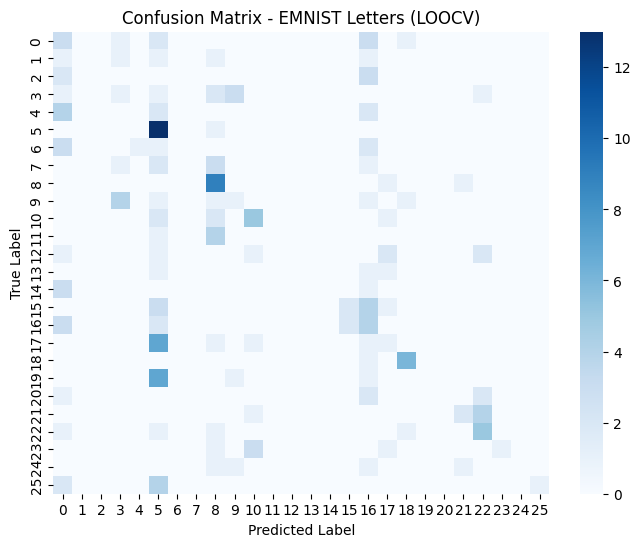

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix - EMNIST Letters (LOOCV)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
subset_size = 200
X_data, y_data = shuffle(X_images, y, random_state=42)
X_data = X_data[:subset_size]
y_data = y_data[:subset_size]

In [ ]:
hog_params_list = [
    {'orientations': 12, 'pixels_per_cell': (4,4), 'cells_per_block': (3,3)},
    {'orientations': 12, 'pixels_per_cell': (4,4), 'cells_per_block': (2,2)},
    {'orientations': 18, 'pixels_per_cell': (4,4), 'cells_per_block': (2,2)},
]

In [ ]:
svm_params_list = [
    {'C': 50, 'gamma': 0.001},
    {'C': 100, 'gamma': 0.001},
    {'C': 100, 'gamma': 0.0005},
]

In [ ]:
best_acc = 0
best_combo = {}

In [ ]:
for h_params in hog_params_list:
    print(f"\nEkstraksi HOG dengan {h_params}")
    X_hog = extract_hog_features(X_data,
                                 orientations=h_params['orientations'],
                                 pixels_per_cell=h_params['pixels_per_cell'],
                                 cells_per_block=h_params['cells_per_block'])

    for s_params in svm_params_list:
        print(f"  SVM params: {s_params}")
        svm_model = SVC(kernel='rbf', C=s_params['C'], gamma=s_params['gamma'])

        loo = LeaveOneOut()
        y_true, y_pred = [], []
        for train_idx, test_idx in tqdm(loo.split(X_hog), total=len(X_hog)):
            X_train, X_test = X_hog[train_idx], X_hog[test_idx]
            y_train, y_test = y_data[train_idx], y_data[test_idx]

            svm_model.fit(X_train, y_train)
            pred = svm_model.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(pred[0])

        acc = accuracy_score(y_true, y_pred)
        print(f"    Accuracy: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_combo = {'hog': h_params, 'svm': s_params}


Ekstraksi HOG dengan {'orientations': 12, 'pixels_per_cell': (4, 4), 'cells_per_block': (3, 3)}
  SVM params: {'C': 50, 'gamma': 0.001}


100%|██████████| 200/200 [00:16<00:00, 12.22it/s]


    Accuracy: 0.5550
  SVM params: {'C': 100, 'gamma': 0.001}


100%|██████████| 200/200 [00:17<00:00, 11.68it/s]


    Accuracy: 0.5700
  SVM params: {'C': 100, 'gamma': 0.0005}


...

    Accuracy: 0.4850
  SVM params: {'C': 100, 'gamma': 0.001}


100%|██████████| 200/200 [00:14<00:00, 14.03it/s]


    Accuracy: 0.4950
  SVM params: {'C': 100, 'gamma': 0.0005}


100%|██████████| 200/200 [00:14<00:00, 13.72it/s]

    Accuracy: 0.4850


In [ ]:
print("\n=== Kombinasi terbaik ===")
print("HOG params:", best_combo['hog'])
print("SVM params:", best_combo['svm'])
print(f"Best Accuracy: {best_acc:.4f}")


=== Kombinasi terbaik ===
HOG params: {'orientations': 12, 'pixels_per_cell': (4, 4), 'cells_per_block': (3, 3)}
SVM params: {'C': 100, 'gamma': 0.001}
Best Accuracy: 0.5700
